Goal: ensure CNN can perform better than random actions in test matches.

In [36]:
import os, sys
import pandas as pd
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add project root so we can import reward
PROJECT_ROOT = Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from reward import compute_rewards_for_episode, RewardWeights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Configuration

In [37]:
# --- Paths ---
DATA_DIR = PROJECT_ROOT / "data" / "test_won_in_area2"
TRAINING_CSV = DATA_DIR / "training_data.csv"
SCREENS_DIR = Path("../input_capture/re_resistance_captures/won_in_area2/screens")

# --- Action space: binary keys + continuous mouse axes ---
# All of these are predicted as independent Q-value heads from the image
KEY_COLUMNS = [
    "mouse_left", "mouse_middle", "mouse_right",
    "key_w", "key_a", "key_s", "key_d",
    "key_q", "key_e", "key_r", "key_f", "key_v", "key_m",
    "key_1", "key_2", "key_3", "key_4",
    "key_space", "key_up", "key_down", "key_left", "key_right",
]
MOUSE_COLUMNS = ["mouse_x", "mouse_y", "mouse_dx", "mouse_dy"]

# Combined output columns: binary keys + mouse axes, each gets its own Q head
OUTPUT_COLUMNS = KEY_COLUMNS + MOUSE_COLUMNS
NUM_OUTPUTS = len(OUTPUT_COLUMNS)

# --- Hyperparameters ---
IMG_SIZE = (84, 84)       # Resize frames for CNN input (DeepMind Atari standard)
STACK_SIZE = 20            # Number of consecutive grayscale frames to stack
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
GAMMA = 0.99              # Discount factor
NUM_EPOCHS = 20
MAX_EARLY_STOP_EPOCHS = 5  # Max extra epochs for early stopping
TRAIN_SPLIT = 0.8

# Loss weights:
#   Active heads  → MSE vs discounted return
#   Inactive heads → L1 toward zero (penalises large Q for unPressed keys)
L1_INACTIVE_WEIGHT = 0.1

print(f"Binary keys: {len(KEY_COLUMNS)}")
print(f"Mouse axes:  {len(MOUSE_COLUMNS)}")
print(f"Total output heads: {NUM_OUTPUTS}")
print(f"CNN input shape: ({STACK_SIZE}, {IMG_SIZE[0]}, {IMG_SIZE[1]})")
print(f"Inactive-head L1 weight: {L1_INACTIVE_WEIGHT}")
print(f"Training CSV: {TRAINING_CSV}")

Binary keys: 22
Mouse axes:  4
Total output heads: 26
CNN input shape: (20, 84, 84)
Inactive-head L1 weight: 0.1
Training CSV: C:\Users\Py Torch\Documents\GitHub\Sillyness\RL_Resistance_MM\modeling\data\test_won_in_area2\training_data.csv


## 2. Load data & compute rewards

In [38]:
df = pd.read_csv(TRAINING_CSV)
print(f"Loaded {len(df)} frames, columns: {list(df.columns)}")

# Compute per-frame rewards using the naive equal-weight reward function
rows = df.to_dict(orient="records")
rewards = compute_rewards_for_episode(rows)
df["reward"] = rewards

# Preprocessing: filter out all rewards/punishments larger than 100
# Highly unlikely this actually happens in a game. Usually a product of poor extraction.
df['reward'].loc[df['reward'].abs() >= 100] = 0

# Preprocessing: manually set starting frame
STARTING_FRAME=391 # after loading + starting white flash
df = df[df['frame'] >= STARTING_FRAME]


# Normalize rewards to zero mean, unit variance
reward_mean = df["reward"].mean()
reward_std = df["reward"].std()
df["reward"] = (df["reward"] - reward_mean) / (reward_std + 1e-8)
print(f"\nReward normalized: mean={reward_mean:.4f}, std={reward_std:.4f}")

# Compute discounted return (target for Q-learning)
returns = np.zeros(len(df))
running = 0.0
for t in reversed(range(len(df))):
    running = df["reward"].iloc[t] + GAMMA * running
    returns[t] = running
df["discounted_return"] = returns

print(f"\nReward stats (normalized):")
print(df["reward"].describe())
print(f"\nDiscounted return stats:")
print(df["discounted_return"].describe())

Loaded 9952 frames, columns: ['frame', 'timestamp', 'mouse_x', 'mouse_y', 'mouse_left', 'mouse_middle', 'mouse_right', 'mouse_dx', 'mouse_dy', 'key_w', 'key_a', 'key_s', 'key_d', 'key_q', 'key_e', 'key_r', 'key_f', 'key_v', 'key_m', 'key_1', 'key_2', 'key_3', 'key_4', 'key_space', 'key_up', 'key_down', 'key_left', 'key_right', 'time_burn_delta', 'bio_energy', 's1_health', 's1_infection', 's2_health', 's2_infection', 's3_health', 's3_infection', 's4_health', 's4_infection', 'camera_status']

Reward normalized: mean=1.2981, std=247.0257

Reward stats (normalized):
count    9.561000e+03
mean    -4.226767e-18
std      1.000000e+00
min     -2.234775e+01
25%     -5.254909e-03
50%     -1.206747e-03
75%      2.841415e-03
max      2.338017e+01
Name: reward, dtype: float64

Discounted return stats:
count    9561.000000
mean        0.006798
std         1.599421
min        -3.867112
25%        -0.393204
50%        -0.111745
75%         0.237733
max        22.399869
Name: discounted_return, dtype: 

C:\Users\Py Torch\AppData\Local\Temp\ipykernel_10960\4217763541.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df['reward'].loc[df['reward'].abs() >= 100] = 0


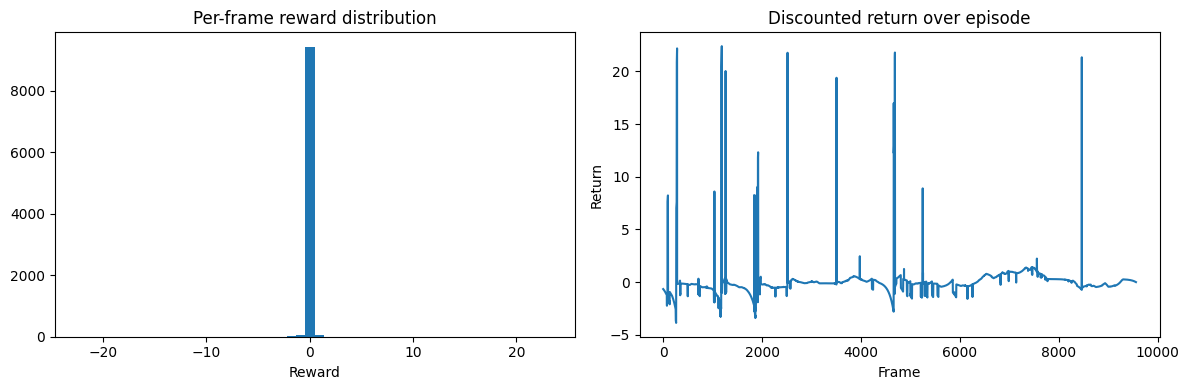

In [39]:
# Quick reward distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["reward"], bins=50)
axes[0].set_title("Per-frame reward distribution")
axes[0].set_xlabel("Reward")
axes[1].plot(df["discounted_return"].values)
axes[1].set_title("Discounted return over episode")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Return")
plt.tight_layout()
plt.show()

## 3. Dataset

In [40]:
class ResistanceDataset(Dataset):
    """Dataset that loads a stack of grayscale frames and returns per-action Q targets.

    Follows the DeepMind Atari DQN convention:
    - Each frame is converted to grayscale (1 channel)
    - STACK_SIZE consecutive frames are stacked along the channel dim → (STACK_SIZE, H, W)
    - Boundary frames (near index 0) are padded by repeating the earliest available frame
    """

    def __init__(self, dataframe: pd.DataFrame, screens_dir: Path, transform=None, stack_size: int = 4):
        self.df = dataframe.reset_index(drop=True)
        self.screens_dir = screens_dir
        self.transform = transform
        self.stack_size = stack_size

    def __len__(self):
        return len(self.df)

    def _load_frame(self, frame_num: int) -> torch.Tensor:
        """Load and transform a single frame. Returns (1, H, W) grayscale tensor."""
        img_path = self.screens_dir / f"frame_{frame_num:06d}.jpg"
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image  # (1, H, W) after grayscale transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Stack STACK_SIZE frames: [t-(k-1), ..., t-1, t], oldest first
        frames = []
        for k in reversed(range(self.stack_size)):
            past_idx = max(0, idx - k)
            past_frame_num = int(self.df.iloc[past_idx]["frame"])
            frames.append(self._load_frame(past_frame_num))

        stacked = torch.cat(frames, dim=0)  # (STACK_SIZE, H, W)

        # Recorded action values for all output dimensions.
        # Binary keys: 0 or 1.  Mouse axes: raw pixel values / deltas.
        # Used in training to build the mask of which heads to update.
        actions = torch.tensor([row[c] for c in OUTPUT_COLUMNS], dtype=torch.float32)

        # Target: discounted return — applied only to active action heads
        target = torch.tensor(row["discounted_return"], dtype=torch.float32)

        return stacked, actions, target

In [41]:
# DeepMind-style preprocessing: grayscale + resize + normalise to [-1, 1]
transform = transforms.Compose([
    transforms.Grayscale(),             # RGB -> 1-channel grayscale
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),              # [0, 255] -> [0.0, 1.0]
    transforms.Normalize(mean=[0.5], std=[0.5]),  # -> [-1.0, 1.0]
])

# Filter to frames that have corresponding images
valid_frames = df["frame"].apply(
    lambda f: (SCREENS_DIR / f"frame_{int(f):06d}.jpg").exists()
)
df_valid = df[valid_frames].copy()
print(f"Frames with images: {len(df_valid)} / {len(df)}")

# Train/val split (temporal — no shuffling across time)
split_idx = int(len(df_valid) * TRAIN_SPLIT)
df_train = df_valid.iloc[:split_idx]
df_val = df_valid.iloc[split_idx:]

train_ds = ResistanceDataset(df_train, SCREENS_DIR, transform=transform, stack_size=STACK_SIZE)
val_ds = ResistanceDataset(df_val, SCREENS_DIR, transform=transform, stack_size=STACK_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

# Sanity check — confirm shapes
sample_stack, sample_actions, sample_target = train_ds[0]
print(f"Stacked frame shape: {sample_stack.shape}  (expected: [{STACK_SIZE}, {IMG_SIZE[0]}, {IMG_SIZE[1]}])")
print(f"Actions shape: {sample_actions.shape}  (expected: [{NUM_OUTPUTS}])")
print(f"Active actions: {(sample_actions != 0).sum().item()} / {NUM_OUTPUTS}")

Frames with images: 9561 / 9561
Train: 7648, Val: 1913
Stacked frame shape: torch.Size([20, 84, 84])  (expected: [20, 84, 84])
Actions shape: torch.Size([26])  (expected: [26])
Active actions: 2 / 26


## 4. Deep Q-Network

In [42]:
class DecomposedQNetwork(nn.Module):
    """Q-function decomposed into independent per-action values.

    Input is a stack of `stack_size` grayscale frames (DeepMind Atari convention).
    Output is a Q-value score for each action dimension (binary keys + mouse axes).
    Training only propagates loss through heads whose action was active in that frame.
    """

    def __init__(self, num_outputs: int, stack_size: int = 4):
        super().__init__()
        self.num_outputs = num_outputs

        # --- 3-layer CNN for visual + temporal features ---
        # Input: stack_size x 84 x 84
        self.cnn = nn.Sequential(
            nn.Conv2d(stack_size, 32, kernel_size=8, stride=4, padding=1), nn.LazyBatchNorm2d(),  # -> 32 x 20 x 20
            nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), nn.LazyBatchNorm2d(),          # -> 64 x 9 x 9
            nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), nn.LazyBatchNorm2d(),          # -> 64 x 7 x 7
            nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
        )
        cnn_out = 64 * 7 * 7  # 3136

        # --- State embedding ---
        self.state_fc = nn.Sequential(
            nn.LazyLinear(4096), nn.LazyBatchNorm1d(),
            nn.ReLU(),
            nn.LazyLinear(256), nn.LazyBatchNorm1d(),
            nn.ReLU(),
        )

        # --- Per-action Q heads (binary keys + mouse axes) ---
        self.action_heads = nn.Linear(256, num_outputs)

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        """Predict Q-value for every action dimension.  

        Args:
            image: (B, stack_size, 84, 84) stacked grayscale frames

        Returns:
            q_values: (B, num_outputs) — one score per action dimension
        """
        x = self.cnn(image)             # (B, 64, 7, 7)
        x = x.view(x.size(0), -1)      # (B, 3136)
        state = self.state_fc(x)        # (B, 256)
        return self.action_heads(state) # (B, num_outputs)

In [43]:
model = DecomposedQNetwork(num_outputs=NUM_OUTPUTS, stack_size=STACK_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Disabling since we use LazyLinears
# total_params = sum(p.numel() for p in model.parameters())
# print(f"Model parameters: {total_params:,}")
print(f"Output heads: {NUM_OUTPUTS} ({len(KEY_COLUMNS)} keys + {len(MOUSE_COLUMNS)} mouse axes)")
print(model)

Output heads: 26 (22 keys + 4 mouse axes)
DecomposedQNetwork(
  (cnn): Sequential(
    (0): Conv2d(20, 32, kernel_size=(8, 8), stride=(4, 4), padding=(1, 1))
    (1): LazyBatchNorm2d(0, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): LazyBatchNorm2d(0, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): LazyBatchNorm2d(0, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (state_fc): Sequential(
    (0): LazyLinear(in_features=0, out_features=4096, bias=True)
    (1): LazyBatchN

## 5. Training loop

In [44]:
def masked_q_loss(
    q_pred: torch.Tensor,
    actions: torch.Tensor,
    targets: torch.Tensor,
    l1_weight: float = L1_INACTIVE_WEIGHT,
) -> torch.Tensor:
    """Combined loss for active and inactive action heads.

    Active heads   (action != 0): MSE vs discounted return.
    Inactive heads (action == 0): L1 toward zero — penalises large Q-values
                                  for actions not taken, without the harsh
                                  quadratic scaling of MSE.

    Args:
        q_pred:    (B, NUM_OUTPUTS) predicted Q-values
        actions:   (B, NUM_OUTPUTS) recorded action values
        targets:   (B,)             discounted return per frame
        l1_weight: scalar weight for the inactive-head penalty
    """
    active   = (actions != 0).float()   # (B, NUM_OUTPUTS)
    inactive = 1.0 - active

    targets_exp = targets.unsqueeze(1).expand_as(q_pred)  # (B, NUM_OUTPUTS)

    # MSE on heads whose action was taken
    n_active = active.sum().clamp(min=1)
    mse_loss = ((q_pred - targets_exp) ** 2 * active).sum() / n_active

    # L1 toward zero on heads whose action was NOT taken
    n_inactive = inactive.sum().clamp(min=1)
    l1_loss = (q_pred.abs() * inactive).sum() / n_inactive

    return mse_loss + l1_weight * l1_loss


def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for images, actions, targets in loader:
        images  = images.to(device)
        actions = actions.to(device)
        targets = targets.to(device)

        q_pred = model(images)
        loss = masked_q_loss(q_pred, actions, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    for images, actions, targets in loader:
        images  = images.to(device)
        actions = actions.to(device)
        targets = targets.to(device)

        q_pred = model(images)
        loss = masked_q_loss(q_pred, actions, targets)

        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)

In [45]:
train_losses = []
val_losses = []

#### Early stopping, minimum of 20 epochs

In [46]:
# Train until loss increases or MAX_EARLY_STOP_EPOCHS is reached
start = 1
end = start+ int(1e6) + MAX_EARLY_STOP_EPOCHS

num_worse_epochs = 0
for epoch in tqdm(range(start, end), desc="Training (early stop)"):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = eval_epoch(model, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    tqdm.write(f"Epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if len(val_losses) >= NUM_EPOCHS and val_loss > val_losses[-2]:
        num_worse_epochs += 1
        if num_worse_epochs > MAX_EARLY_STOP_EPOCHS:
            tqdm.write(f"Validation loss increased ({val_losses[-2]:.4f} -> {val_loss:.4f}), stopping.")
            break

print(f"\nStopped after {len(train_losses)} total epochs.")

Training (early stop):   0%|          | 1/1000005 [29:19<488752:43:57, 1759.50s/it]

Epoch   1  train_loss=2.7067  val_loss=1.0796


Training (early stop):   0%|          | 2/1000005 [58:15<484987:27:19, 1745.95s/it]

Epoch   2  train_loss=2.1301  val_loss=1.1112


Training (early stop):   0%|          | 3/1000005 [1:27:15<484188:00:00, 1743.07s/it]

...

Epoch  34  train_loss=0.3945  val_loss=0.7611


Training (early stop):   0%|          | 35/1000005 [16:51:06<495266:34:43, 1783.01s/it]

Epoch  35  train_loss=0.2603  val_loss=0.5526


Training (early stop):   0%|          | 35/1000005 [17:20:29<495456:10:58, 1783.70s/it]

Epoch  36  train_loss=0.3007  val_loss=0.7180
Validation loss increased (0.5526 -> 0.7180), stopping.

Stopped after 36 total epochs.


note: 3/1/2026 CNN implementation, 20-30 epochs seems to be the sweet spot

## 6. Results

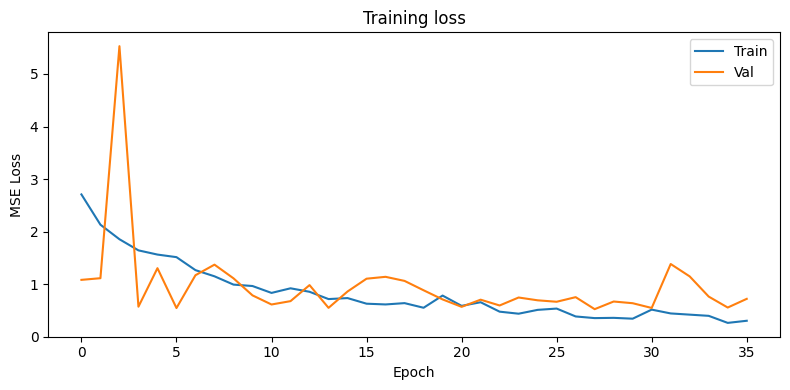

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Train")
ax.plot(val_losses, label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training loss")
ax.legend()
plt.tight_layout()
plt.show()

In [49]:
# Save model checkpoint
import datetime

today = datetime.date.today().strftime("%Y-%m-%d")


ckpt_path = PROJECT_ROOT / "checkpoints"
ckpt_path.mkdir(exist_ok=True)
model_output_name = f"{today}-deep_q_v1.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "key_columns": KEY_COLUMNS,
    "NUM_OUTPUTS": NUM_OUTPUTS,
}, ckpt_path / model_output_name)
print(f"Saved checkpoint to {ckpt_path / f"{model_output_name}"}")

Saved checkpoint to C:\Users\Py Torch\Documents\GitHub\Sillyness\RL_Resistance_MM\modeling\checkpoints\2026-03-01-deep_q_v1.pt
